# Matplotlib 常用用法

- 折线图、柱状图、散点图、直方图和图片保存；
- 训练集/验证集的 Loss、Accuracy 曲线；
- 模型指标对比、类别分布、混淆矩阵；
- ROC、PR、残差、特征重要性、超参数热力图；
- 多子图布局、坐标轴、图例、刻度、标注和参考线；
- NumPy、Pandas、PyTorch 数据与 Matplotlib 的衔接；
- 可复用绘图函数、常见错误和快速速查表。
  
> **准备数据 → 创建 Figure/Axes → 绘制图形 → 补充语义 → 调整布局 → 保存或显示。**

## 目录

1. 导入与统一设置  
2. `Figure`、`Axes` 与两种绘图方式  
3. 常见基础图形  
4. 坐标轴、图例、标注与布局  
5. 机器学习训练过程可视化  
6. 分类任务常见图形  
7. 回归任务与特征分析  
8. 图像数据与超参数实验  
9. NumPy、Pandas、PyTorch 衔接  
10. 可复用函数  
11. 图片保存与资源管理  
12. 常见错误与速查表  
13. 综合练习

## 1. 导入与统一设置

常见约定：

```python
import matplotlib.pyplot as plt
```

- `plt` 是 `matplotlib.pyplot` 的常用别名；
- `NumPy` 负责准备数值数据；
- `Pandas` 适合表格数据；
- 机器学习项目中推荐优先使用 **面向对象写法**：`fig, ax = plt.subplots()`。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 让随机示例可复现。
rng = np.random.default_rng(42)

# Notebook 中常用的全局显示设置。
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"

print("Matplotlib version:", plt.matplotlib.__version__)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-88sjef0d because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib version: 3.10.8


### 一张图最常见的完整流程

```python
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set(
    title="Title",
    xlabel="X",
    ylabel="Y",
)
ax.grid(True)
fig.tight_layout()
plt.show()
```

- `fig`：整张画布；
- `ax`：画布中的一个坐标区域；
- 真正的折线、坐标轴标题和图例通常都由 `ax` 控制。

## 2. `Figure`、`Axes` 与两种绘图方式

### 2.1 `pyplot` 写法

适合临时、简单的单图。

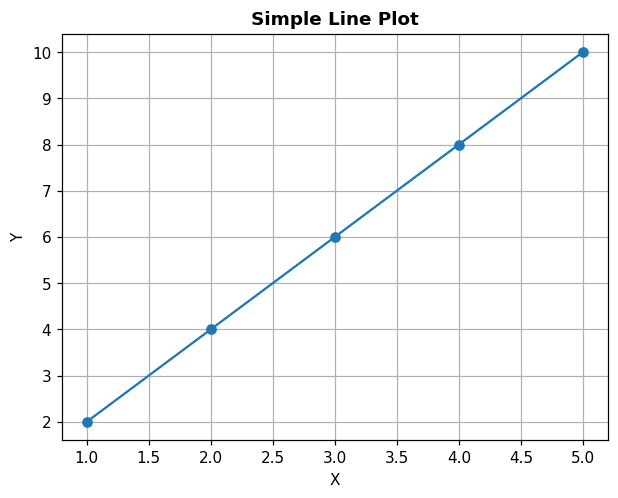

In [2]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

plt.plot(x, y, marker="o")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Simple Line Plot")
plt.grid(True)
plt.show()

### 2.2 面向对象写法

复杂图、多个子图和项目代码中更推荐。  
它能明确指出“正在修改哪一个坐标区域”，不容易在多图时混乱。

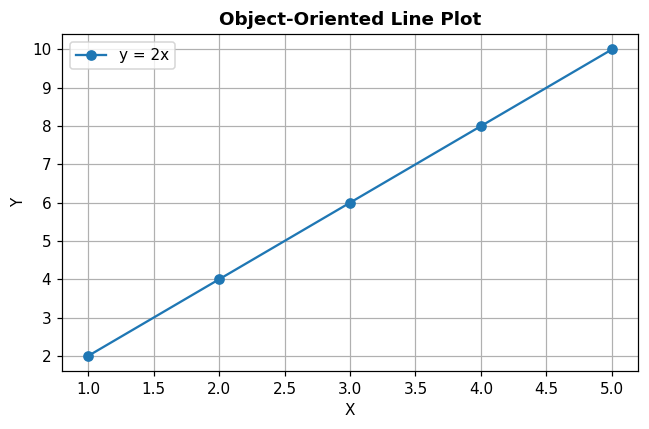

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(x, y, marker="o", label="y = 2x")
ax.set(
    title="Object-Oriented Line Plot",
    xlabel="X",
    ylabel="Y",
)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

### 2.3 `figsize`、`dpi` 和返回值

```python
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
```

- `figsize=(宽, 高)`：单位是英寸；
- `dpi`：每英寸像素数，影响显示和输出清晰度；
- `plt.subplots()` 返回 `(Figure, Axes)`。

## 3. 常见基础图形

| 图形 | 常用方法 | 机器学习中的典型用途 |
|---|---|---|
| 折线图 | `ax.plot()` | Loss、Accuracy、学习率变化 |
| 散点图 | `ax.scatter()` | 特征关系、真实值与预测值 |
| 柱状图 | `ax.bar()` / `ax.barh()` | 模型指标、类别数量、特征重要性 |
| 直方图 | `ax.hist()` | 数值分布、预测概率、残差 |
| 箱线图 | `ax.boxplot()` | 异常值、多个模型多次实验结果 |
| 误差棒 | `ax.errorbar()` | 均值及标准差/置信区间 |
| 图片/矩阵 | `ax.imshow()` | 图片、混淆矩阵、热力图 |

### 3.1 折线图 `plot()`

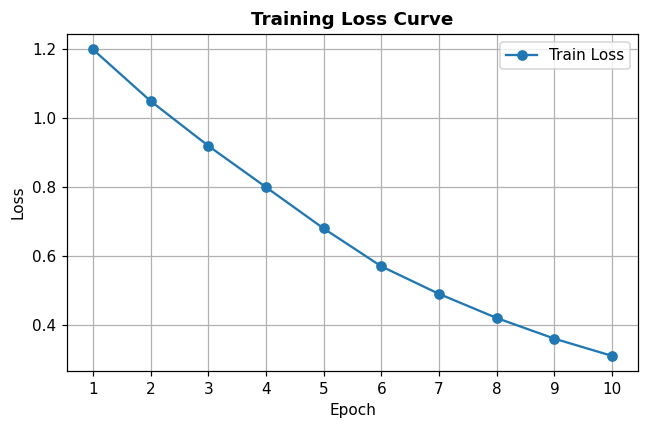

In [4]:
epochs = np.arange(1, 11)
train_loss = np.array([1.20, 1.05, 0.92, 0.80, 0.68, 0.57, 0.49, 0.42, 0.36, 0.31])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs, train_loss, marker="o", label="Train Loss")
ax.set(
    title="Training Loss Curve",
    xlabel="Epoch",
    ylabel="Loss",
)
ax.set_xticks(epochs)
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

`plot()` 常见参数：

- `marker="o"`：显示数据点；
- `linestyle="--"`：虚线；
- `linewidth=2`：线宽；
- `label="Train"`：图例名称；
- `alpha=0.7`：透明度。

项目中不需要每次都设置全部参数，默认样式通常已经足够。

### 3.2 散点图 `scatter()`

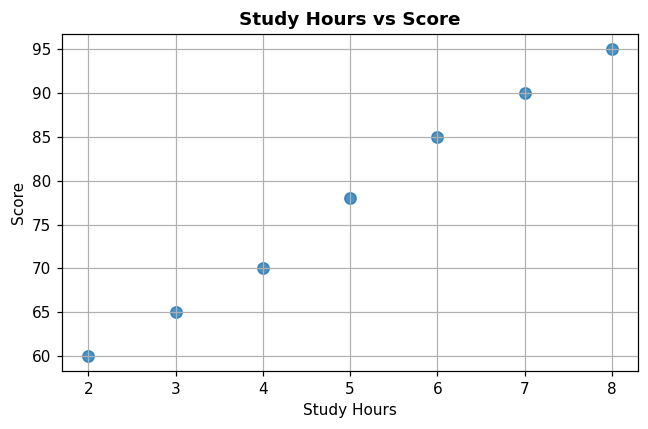

In [5]:
study_hours = np.array([2, 3, 4, 5, 6, 7, 8])
scores = np.array([60, 65, 70, 78, 85, 90, 95])

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(study_hours, scores, s=55, alpha=0.8)
ax.set(
    title="Study Hours vs Score",
    xlabel="Study Hours",
    ylabel="Score",
)
ax.grid(True)
fig.tight_layout()
plt.show()

散点图适合观察：

- 两个连续特征是否相关；
- 分类样本是否能够分开；
- 预测值与真实值是否接近；
- 是否存在异常点。

`s` 控制点的面积，`alpha` 控制透明度。

### 3.3 柱状图 `bar()` 与水平柱状图 `barh()`

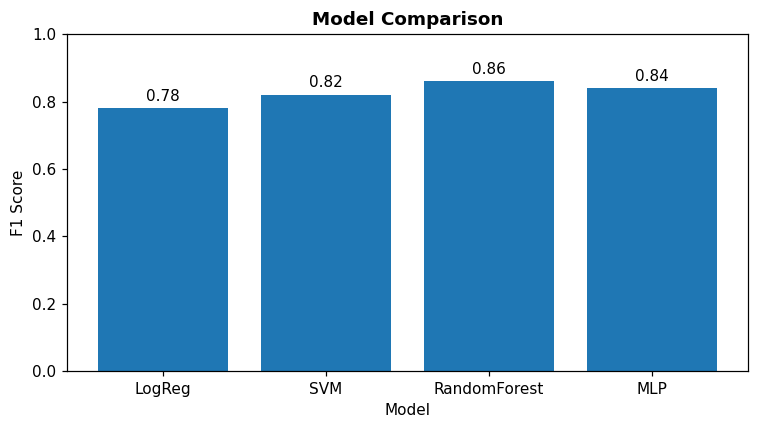

In [6]:
models = ["LogReg", "SVM", "RandomForest", "MLP"]
f1_scores = np.array([0.78, 0.82, 0.86, 0.84])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, f1_scores)

ax.set(
    title="Model Comparison",
    xlabel="Model",
    ylabel="F1 Score",
)
ax.set_ylim(0, 1)
ax.bar_label(bars, fmt="%.2f", padding=3)

fig.tight_layout()
plt.show()

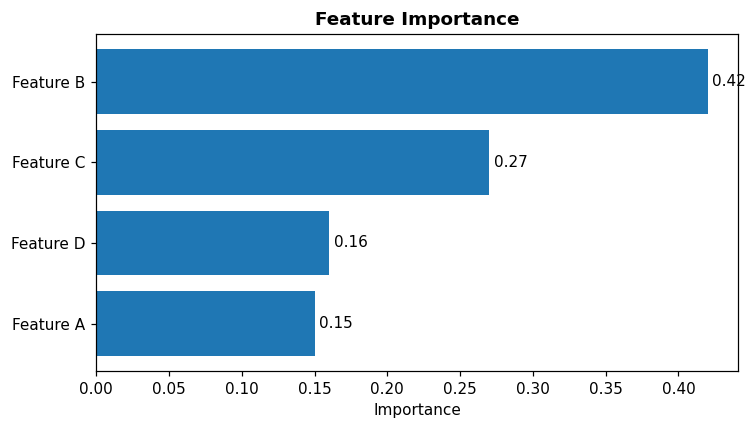

In [7]:
feature_names = ["Feature A", "Feature B", "Feature C", "Feature D"]
importances = np.array([0.15, 0.42, 0.27, 0.16])

order = np.argsort(importances)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    np.array(feature_names)[order],
    importances[order],
)
ax.set(
    title="Feature Importance",
    xlabel="Importance",
)
ax.bar_label(bars, fmt="%.2f", padding=3)

fig.tight_layout()
plt.show()

### 3.4 直方图 `hist()`

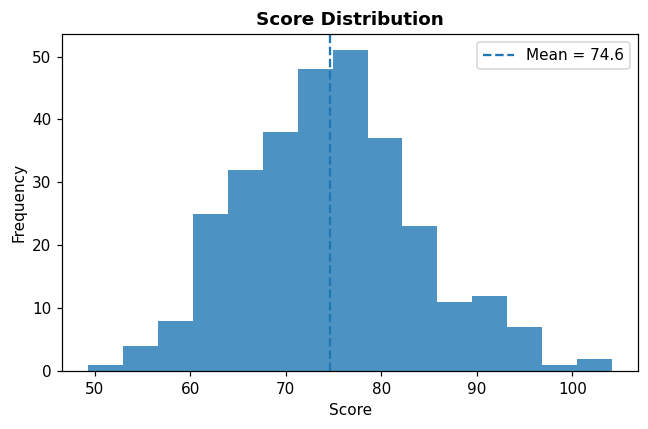

In [8]:
random_scores = rng.normal(loc=75, scale=10, size=300)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(random_scores, bins=15, alpha=0.8)
ax.axvline(random_scores.mean(), linestyle="--", label=f"Mean = {random_scores.mean():.1f}")
ax.set(
    title="Score Distribution",
    xlabel="Score",
    ylabel="Frequency",
)
ax.legend()

fig.tight_layout()
plt.show()

- `bins`：区间数量；太少会丢失细节，太多会显得噪声很大；
- `density=True`：纵轴显示概率密度，而不是样本数量；
- 直方图主要看分布形状，不要只看均值。

### 3.5 箱线图 `boxplot()`

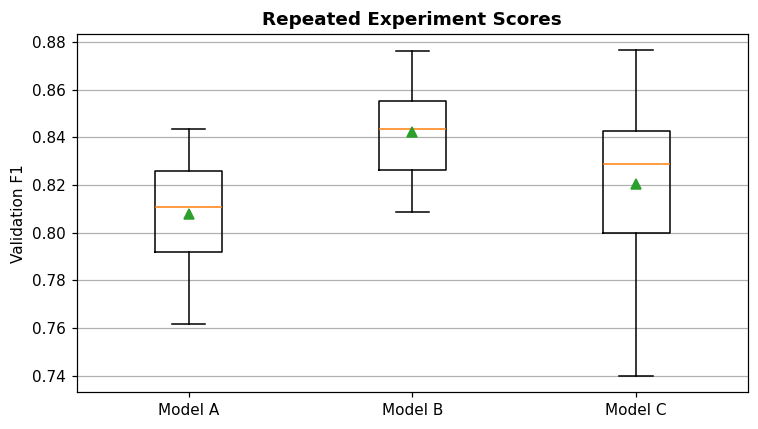

In [9]:
experiment_scores = [
    rng.normal(0.80, 0.025, size=20),
    rng.normal(0.84, 0.020, size=20),
    rng.normal(0.82, 0.035, size=20),
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(
    experiment_scores,
    tick_labels=["Model A", "Model B", "Model C"],
    showmeans=True,
)
ax.set(
    title="Repeated Experiment Scores",
    ylabel="Validation F1",
)
ax.grid(True, axis="y")

fig.tight_layout()
plt.show()

箱线图常用于多次实验结果：

- 中间线：中位数；
- 箱体：上下四分位数；
- 须：主要数据范围；
- 独立点：可能的异常值。

它比只汇报一次最高分更能反映模型稳定性。

### 3.6 误差棒和置信区域

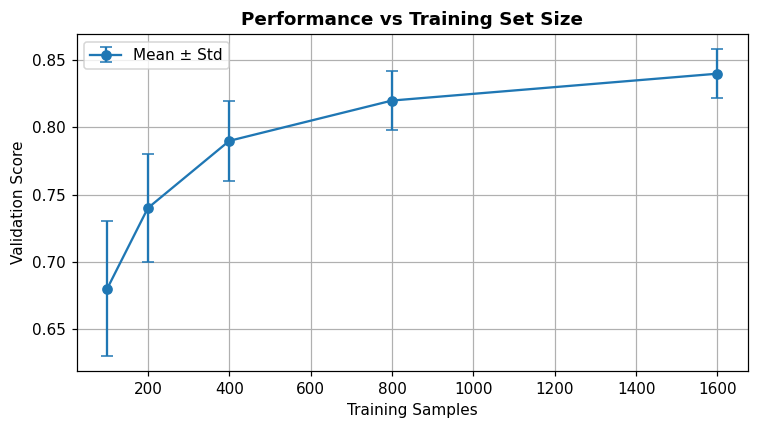

In [10]:
sample_sizes = np.array([100, 200, 400, 800, 1600])
mean_scores = np.array([0.68, 0.74, 0.79, 0.82, 0.84])
std_scores = np.array([0.050, 0.040, 0.030, 0.022, 0.018])

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    sample_sizes,
    mean_scores,
    yerr=std_scores,
    marker="o",
    capsize=4,
    label="Mean ± Std",
)
ax.set(
    title="Performance vs Training Set Size",
    xlabel="Training Samples",
    ylabel="Validation Score",
)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

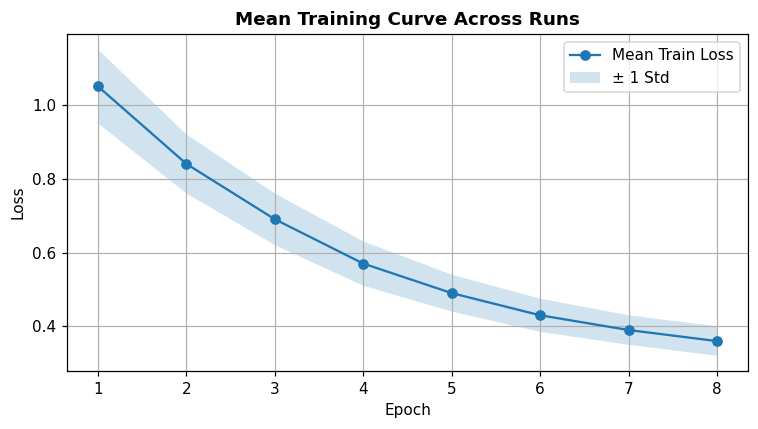

In [11]:
mean_loss = np.array([1.05, 0.84, 0.69, 0.57, 0.49, 0.43, 0.39, 0.36])
std_loss = np.array([0.10, 0.08, 0.07, 0.06, 0.05, 0.045, 0.04, 0.04])
epochs_short = np.arange(1, len(mean_loss) + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs_short, mean_loss, marker="o", label="Mean Train Loss")
ax.fill_between(
    epochs_short,
    mean_loss - std_loss,
    mean_loss + std_loss,
    alpha=0.2,
    label="± 1 Std",
)
ax.set(
    title="Mean Training Curve Across Runs",
    xlabel="Epoch",
    ylabel="Loss",
)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

## 4. 坐标轴、图例、标注与布局

### 4.1 `set()` 与常见坐标轴设置

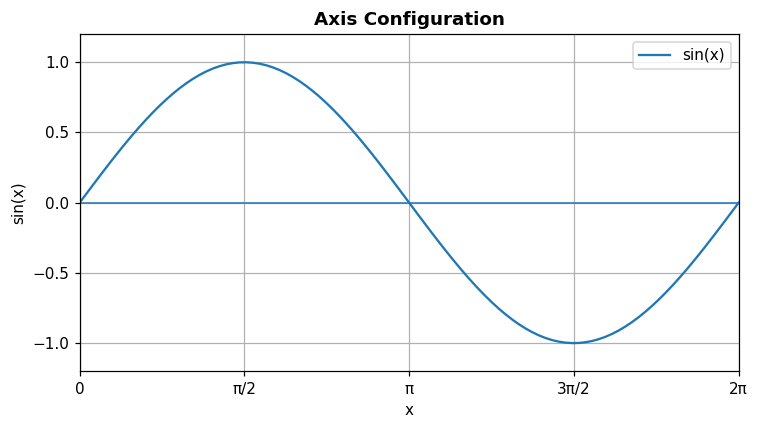

In [12]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, label="sin(x)")
ax.set(
    title="Axis Configuration",
    xlabel="x",
    ylabel="sin(x)",
    xlim=(0, 2 * np.pi),
    ylim=(-1.2, 1.2),
)
ax.set_xticks(
    [0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
    ["0", "π/2", "π", "3π/2", "2π"],
)
ax.axhline(0, linewidth=1)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

常见方法：

```python
ax.set_title(...)
ax.set_xlabel(...)
ax.set_ylabel(...)
ax.set_xlim(...)
ax.set_ylim(...)
ax.set_xticks(...)
ax.set_yticks(...)
ax.legend(...)
ax.grid(...)
```

`ax.set(...)` 可以一次设置多个属性。

### 4.2 参考线、区域和文本标注

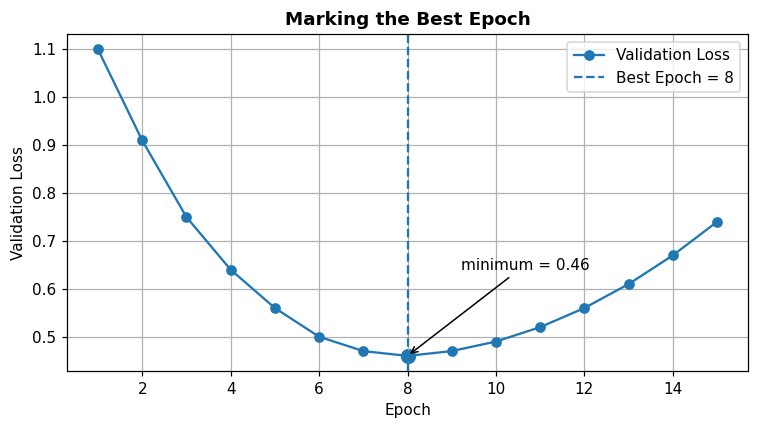

In [13]:
epochs_demo = np.arange(1, 16)
val_loss_demo = np.array([
    1.10, 0.91, 0.75, 0.64, 0.56,
    0.50, 0.47, 0.46, 0.47, 0.49,
    0.52, 0.56, 0.61, 0.67, 0.74,
])
best_epoch = int(epochs_demo[np.argmin(val_loss_demo)])
best_loss = float(val_loss_demo.min())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs_demo, val_loss_demo, marker="o", label="Validation Loss")
ax.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
ax.scatter([best_epoch], [best_loss], s=80)
ax.annotate(
    f"minimum = {best_loss:.2f}",
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 1.2, best_loss + 0.18),
    arrowprops={"arrowstyle": "->"},
)
ax.set(
    title="Marking the Best Epoch",
    xlabel="Epoch",
    ylabel="Validation Loss",
)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

### 4.3 多子图 `subplots()`

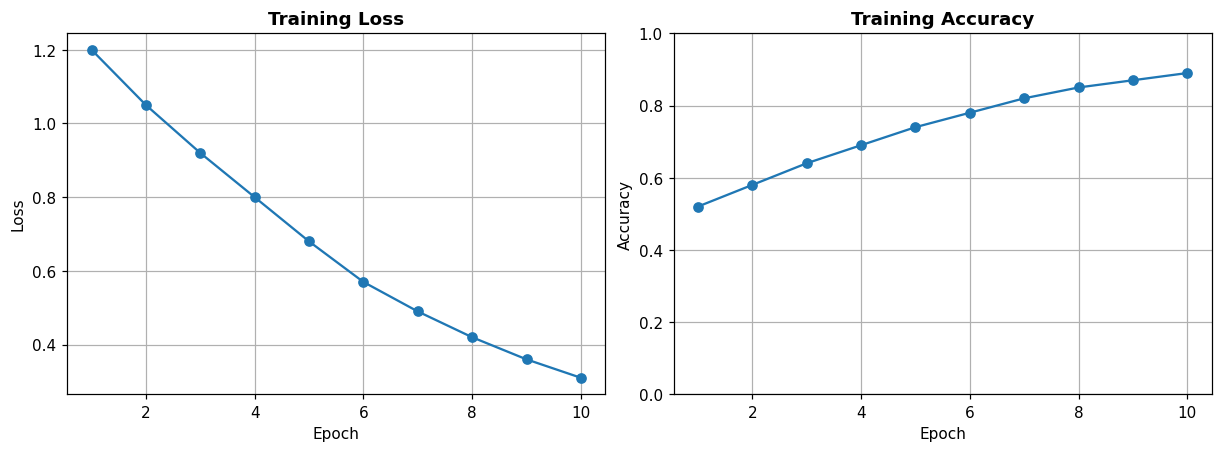

In [14]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11, 4),
    constrained_layout=True,
)

axes[0].plot(epochs, train_loss, marker="o")
axes[0].set(
    title="Training Loss",
    xlabel="Epoch",
    ylabel="Loss",
)
axes[0].grid(True)

train_accuracy = np.array([0.52, 0.58, 0.64, 0.69, 0.74, 0.78, 0.82, 0.85, 0.87, 0.89])
axes[1].plot(epochs, train_accuracy, marker="o")
axes[1].set(
    title="Training Accuracy",
    xlabel="Epoch",
    ylabel="Accuracy",
    ylim=(0, 1),
)
axes[1].grid(True)

plt.show()

布局常用参数：

- `nrows`、`ncols`：行数与列数；
- `figsize`：整张画布大小；
- `sharex=True` / `sharey=True`：共享坐标轴；
- `constrained_layout=True`：自动减少元素重叠；
- `fig.tight_layout()`：绘制完成后自动调整间距。

> Loss 和 Accuracy 的量纲不同，通常分成两个子图比画在同一个纵轴上更清晰。

### 4.4 对数坐标

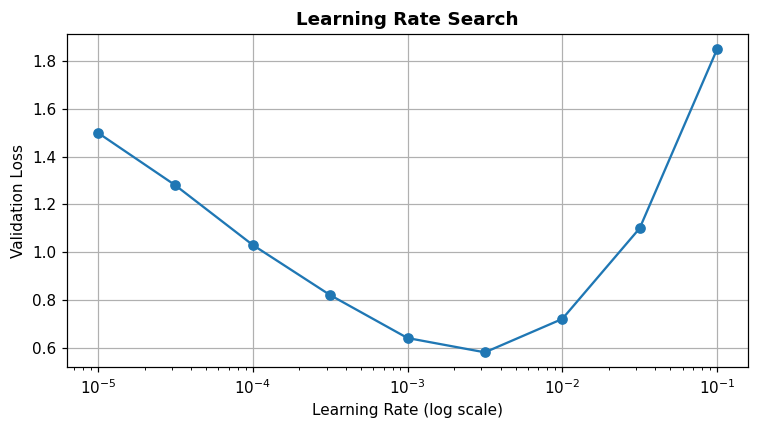

In [15]:
learning_rates = np.logspace(-5, -1, 9)
validation_loss = np.array([1.50, 1.28, 1.03, 0.82, 0.64, 0.58, 0.72, 1.10, 1.85])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(learning_rates, validation_loss, marker="o")
ax.set_xscale("log")
ax.set(
    title="Learning Rate Search",
    xlabel="Learning Rate (log scale)",
    ylabel="Validation Loss",
)
ax.grid(True)

fig.tight_layout()
plt.show()

对数坐标适合跨度很大的变量，例如：

- 学习率：`1e-5` 到 `1e-1`；
- 损失值跨越多个数量级；
- 参数量、运行时间和数据规模。

## 5. 机器学习训练过程可视化

训练日志中最常见的数据结构：

```python
history = {
    "train_loss": [...],
    "val_loss": [...],
    "train_acc": [...],
    "val_acc": [...],
}
```

In [16]:
history = {
    "train_loss": [1.20, 0.98, 0.80, 0.66, 0.55, 0.46, 0.39, 0.34, 0.30, 0.27, 0.24, 0.22],
    "val_loss":   [1.25, 1.02, 0.84, 0.71, 0.62, 0.57, 0.54, 0.53, 0.54, 0.57, 0.61, 0.66],
    "train_acc":  [0.48, 0.59, 0.67, 0.73, 0.78, 0.82, 0.85, 0.88, 0.90, 0.92, 0.94, 0.95],
    "val_acc":    [0.46, 0.57, 0.65, 0.71, 0.75, 0.78, 0.80, 0.81, 0.81, 0.80, 0.79, 0.78],
}

### 5.1 训练集与验证集曲线

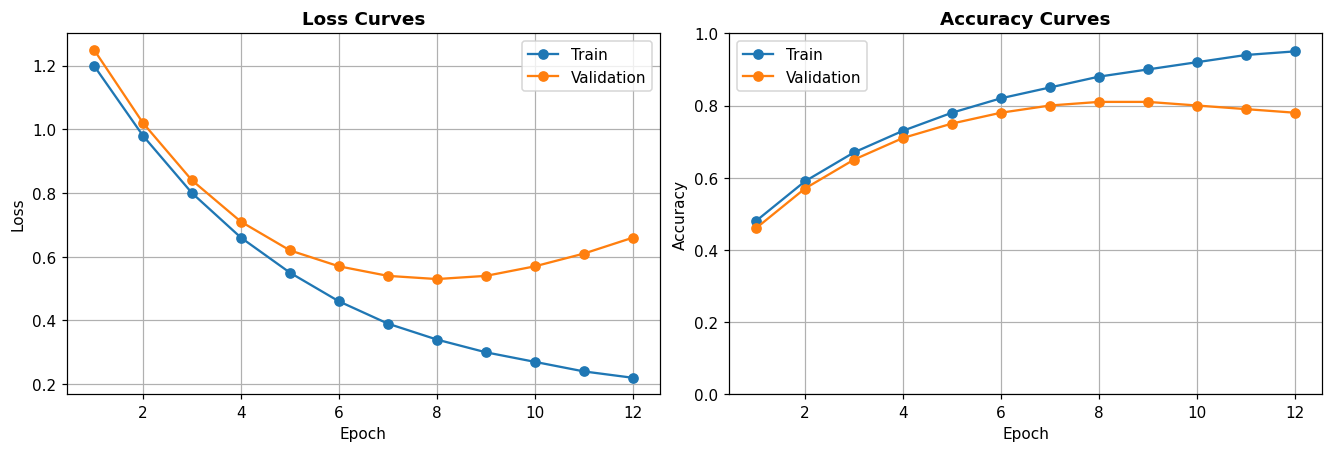

In [17]:
epochs_history = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(epochs_history, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs_history, history["val_loss"], marker="o", label="Validation")
axes[0].set(
    title="Loss Curves",
    xlabel="Epoch",
    ylabel="Loss",
)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_history, history["train_acc"], marker="o", label="Train")
axes[1].plot(epochs_history, history["val_acc"], marker="o", label="Validation")
axes[1].set(
    title="Accuracy Curves",
    xlabel="Epoch",
    ylabel="Accuracy",
    ylim=(0, 1),
)
axes[1].legend()
axes[1].grid(True)

plt.show()

### 如何读训练曲线

- 训练 Loss 下降、验证 Loss 也下降：模型正在有效学习；
- 训练 Loss 继续下降、验证 Loss 开始上升：出现过拟合迹象；
- 训练和验证表现都较差：可能欠拟合；
- 曲线剧烈震荡：学习率可能过大，或 batch 较小；
- 两条曲线相差很大：需要关注泛化能力、数据分布或数据泄漏。

不能只看最后一个 Epoch，应结合验证集选择模型。

### 5.2 自动标记最佳 Epoch

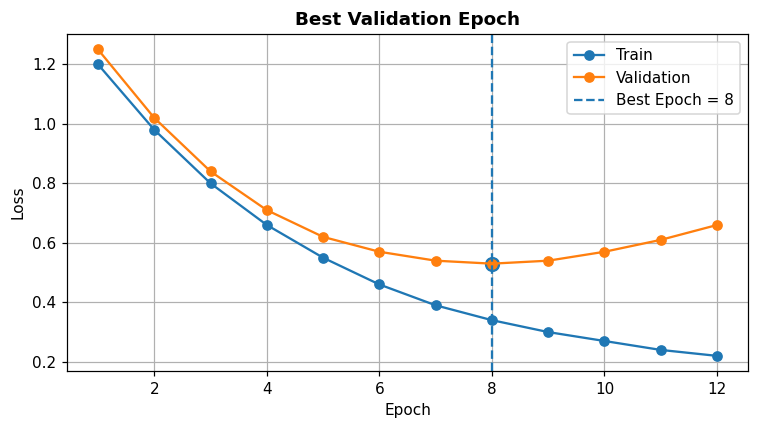

Best epoch: 8
Best validation loss: 0.53


In [18]:
val_losses = np.asarray(history["val_loss"])
best_index = int(np.argmin(val_losses))
best_epoch = best_index + 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs_history, history["train_loss"], marker="o", label="Train")
ax.plot(epochs_history, history["val_loss"], marker="o", label="Validation")
ax.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
ax.scatter([best_epoch], [val_losses[best_index]], s=80)
ax.set(
    title="Best Validation Epoch",
    xlabel="Epoch",
    ylabel="Loss",
)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

print("Best epoch:", best_epoch)
print("Best validation loss:", round(float(val_losses[best_index]), 4))

### 5.3 多个实验的曲线比较

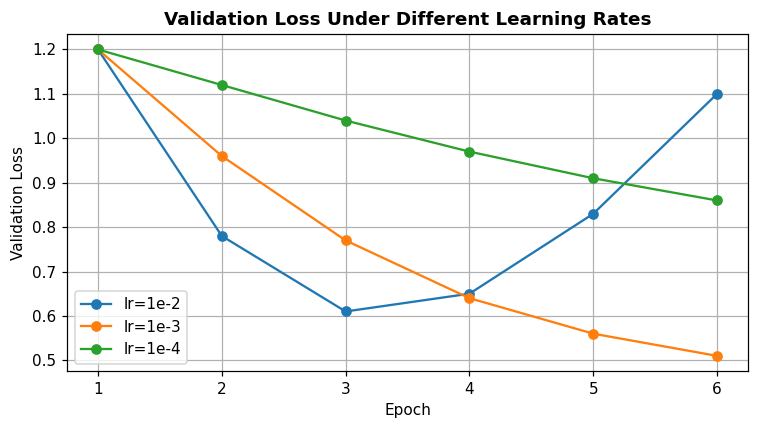

In [19]:
experiments = {
    "lr=1e-2": [1.20, 0.78, 0.61, 0.65, 0.83, 1.10],
    "lr=1e-3": [1.20, 0.96, 0.77, 0.64, 0.56, 0.51],
    "lr=1e-4": [1.20, 1.12, 1.04, 0.97, 0.91, 0.86],
}

fig, ax = plt.subplots(figsize=(7, 4))
for label, values in experiments.items():
    experiment_epochs = np.arange(1, len(values) + 1)
    ax.plot(experiment_epochs, values, marker="o", label=label)

ax.set(
    title="Validation Loss Under Different Learning Rates",
    xlabel="Epoch",
    ylabel="Validation Loss",
)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

## 6. 分类任务常见图形

### 6.1 类别分布

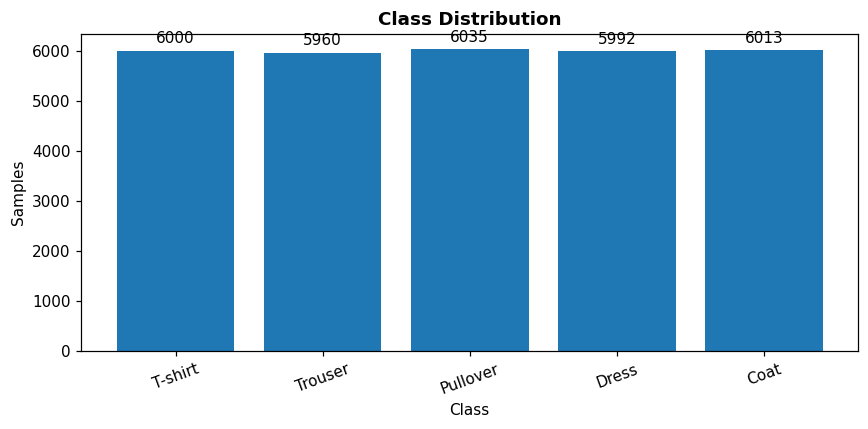

In [20]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat"]
class_counts = np.array([6000, 5960, 6035, 5992, 6013])

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(class_names, class_counts)
ax.set(
    title="Class Distribution",
    xlabel="Class",
    ylabel="Samples",
)
ax.bar_label(bars, padding=3)
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()

类别分布图可以帮助判断：

- 是否类别不均衡；
- Accuracy 是否可能具有误导性；
- 是否需要重采样、类别权重或更合适的评价指标。

### 6.2 混淆矩阵 `imshow()`

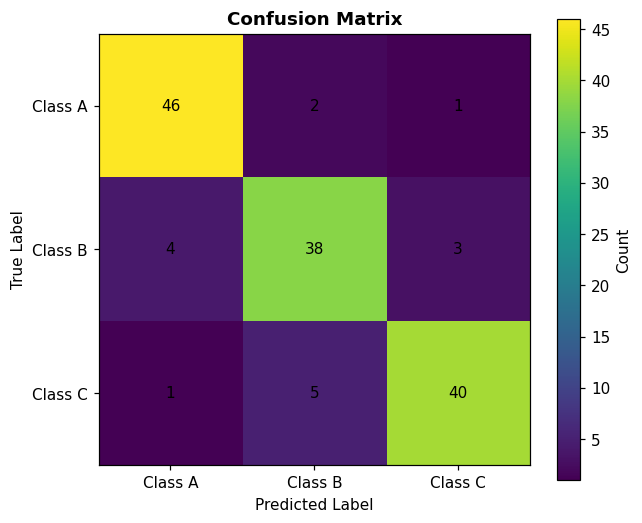

In [21]:
confusion_matrix = np.array([
    [46,  2,  1],
    [ 4, 38,  3],
    [ 1,  5, 40],
])
cm_labels = ["Class A", "Class B", "Class C"]

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion_matrix)

ax.set(
    title="Confusion Matrix",
    xlabel="Predicted Label",
    ylabel="True Label",
)
ax.set_xticks(np.arange(len(cm_labels)), cm_labels)
ax.set_yticks(np.arange(len(cm_labels)), cm_labels)

for row in range(confusion_matrix.shape[0]):
    for col in range(confusion_matrix.shape[1]):
        ax.text(
            col,
            row,
            str(confusion_matrix[row, col]),
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Count")
fig.tight_layout()
plt.show()

混淆矩阵的阅读方式：

- 行：真实类别；
- 列：预测类别；
- 对角线：预测正确；
- 非对角线：具体混淆到哪个类别。

二分类中可进一步对应 TP、FP、TN、FN。

### 6.3 预测概率分布

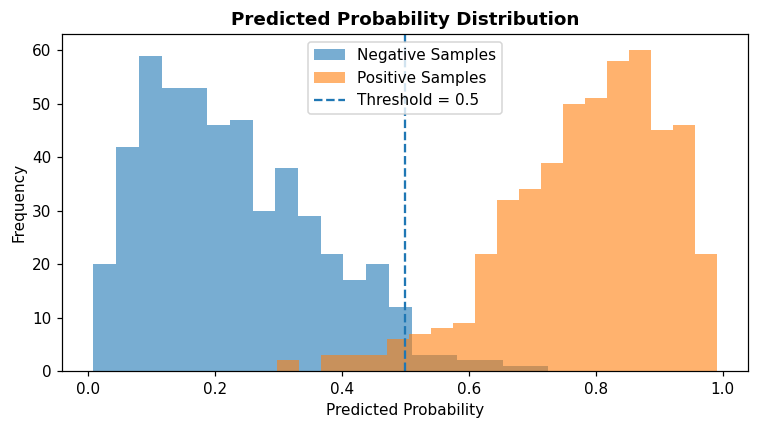

In [22]:
negative_probs = rng.beta(2, 7, size=500)
positive_probs = rng.beta(7, 2, size=500)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(negative_probs, bins=20, alpha=0.6, label="Negative Samples")
ax.hist(positive_probs, bins=20, alpha=0.6, label="Positive Samples")
ax.axvline(0.5, linestyle="--", label="Threshold = 0.5")
ax.set(
    title="Predicted Probability Distribution",
    xlabel="Predicted Probability",
    ylabel="Frequency",
)
ax.legend()

fig.tight_layout()
plt.show()

预测概率图能帮助观察：

- 正负样本是否容易分开；
- 当前阈值是否合理；
- 是否有大量样本集中在 0.5 附近；
- 模型是否过度自信。

### 6.4 ROC 曲线

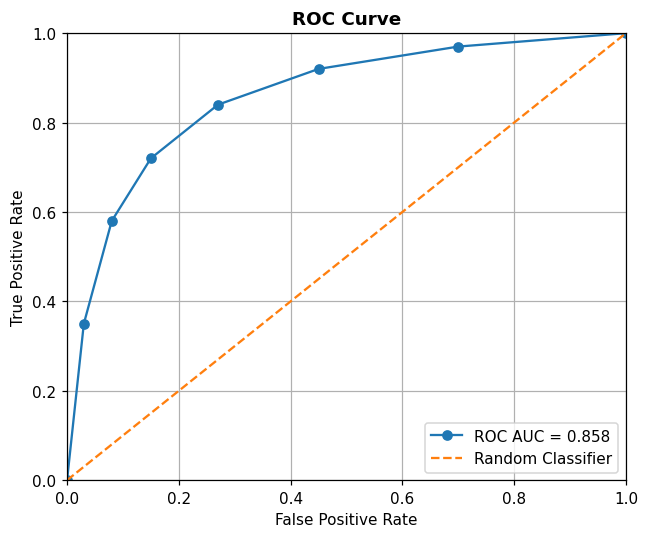

In [23]:
false_positive_rate = np.array([0.00, 0.03, 0.08, 0.15, 0.27, 0.45, 0.70, 1.00])
true_positive_rate = np.array([0.00, 0.35, 0.58, 0.72, 0.84, 0.92, 0.97, 1.00])
roc_auc = np.trapezoid(true_positive_rate, false_positive_rate)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(false_positive_rate, true_positive_rate, marker="o", label=f"ROC AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
ax.set(
    title="ROC Curve",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

### 6.5 Precision–Recall 曲线

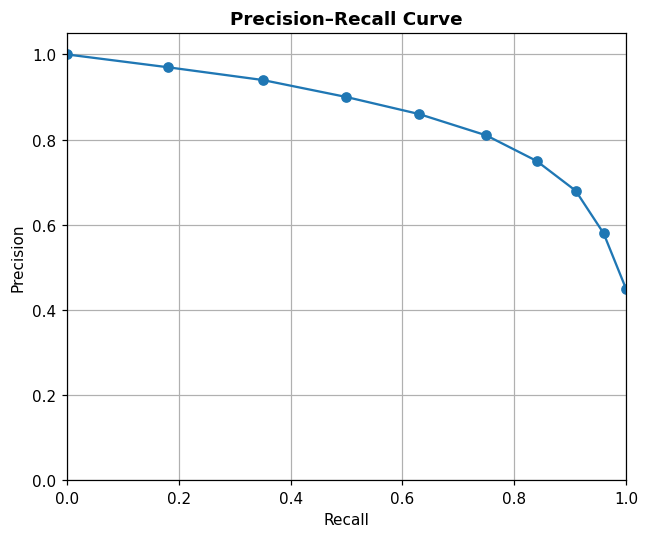

In [24]:
recall = np.array([0.00, 0.18, 0.35, 0.50, 0.63, 0.75, 0.84, 0.91, 0.96, 1.00])
precision = np.array([1.00, 0.97, 0.94, 0.90, 0.86, 0.81, 0.75, 0.68, 0.58, 0.45])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, marker="o")
ax.set(
    title="Precision–Recall Curve",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1.05),
)
ax.grid(True)

fig.tight_layout()
plt.show()

- ROC 观察 TPR 与 FPR 的权衡；
- PR 曲线观察 Precision 与 Recall 的权衡；
- 类别严重不均衡时，PR 曲线通常更值得关注；
- 绘制曲线应使用连续预测分数或概率，而不是最终的 0/1 类别。

## 7. 回归任务与特征分析

### 7.1 真实值与预测值

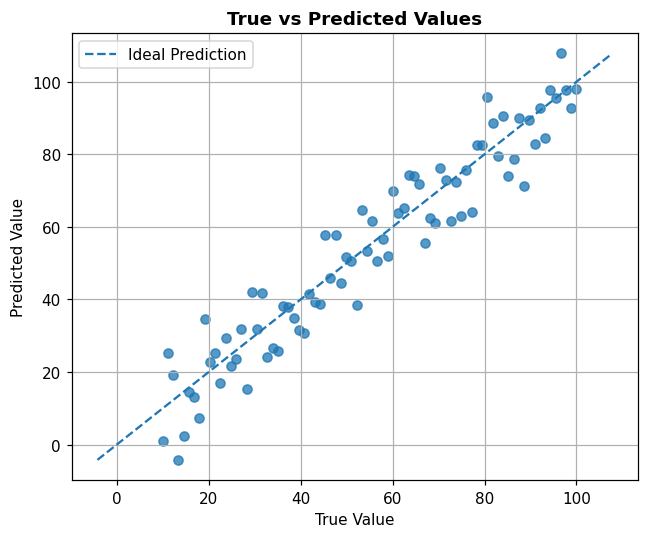

In [25]:
y_true = np.linspace(10, 100, 80)
y_pred = y_true + rng.normal(0, 8, size=y_true.size)

lower = min(y_true.min(), y_pred.min())
upper = max(y_true.max(), y_pred.max())

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_true, y_pred, alpha=0.75)
ax.plot([lower, upper], [lower, upper], linestyle="--", label="Ideal Prediction")
ax.set(
    title="True vs Predicted Values",
    xlabel="True Value",
    ylabel="Predicted Value",
)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

点越接近对角线，预测越接近真实值。  
系统性偏离对角线可能表示模型存在整体高估或低估。

### 7.2 残差图

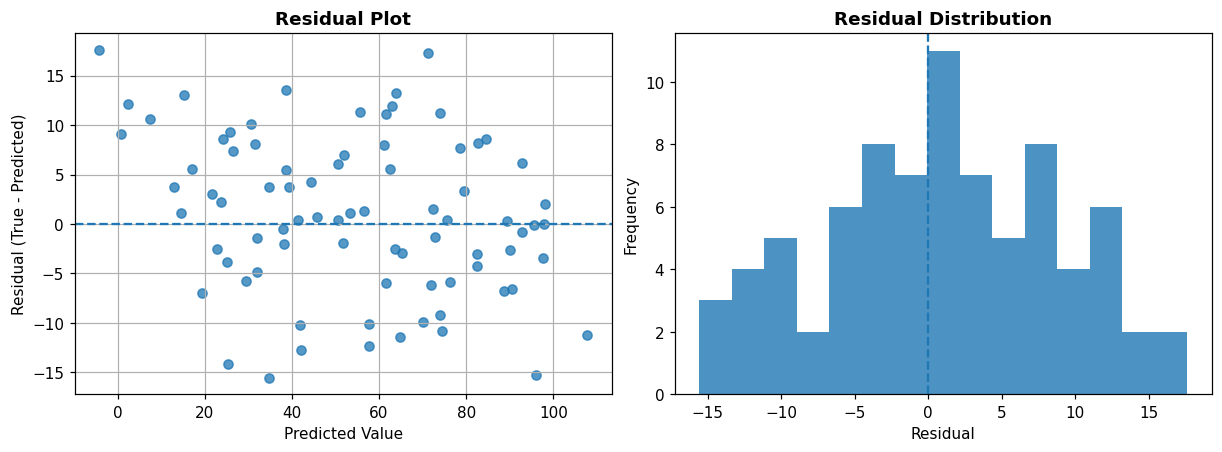

In [26]:
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].scatter(y_pred, residuals, alpha=0.75)
axes[0].axhline(0, linestyle="--")
axes[0].set(
    title="Residual Plot",
    xlabel="Predicted Value",
    ylabel="Residual (True - Predicted)",
)
axes[0].grid(True)

axes[1].hist(residuals, bins=15, alpha=0.8)
axes[1].axvline(0, linestyle="--")
axes[1].set(
    title="Residual Distribution",
    xlabel="Residual",
    ylabel="Frequency",
)

plt.show()

理想残差通常：

- 大致围绕 0 随机分布；
- 不随预测值出现明显扩大或缩小；
- 不表现出明显曲线结构；
- 极端异常值较少。

残差有规律，说明模型可能遗漏了某些关系。

### 7.3 相关系数矩阵

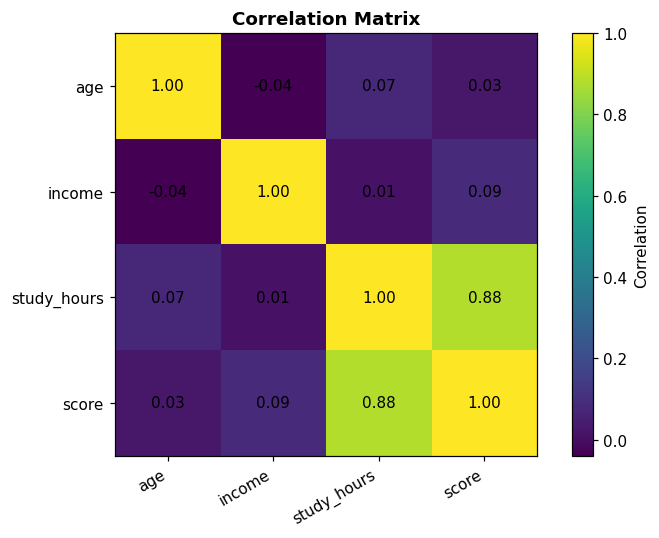

In [27]:
feature_df = pd.DataFrame({
    "age": rng.integers(18, 70, size=120),
    "income": rng.normal(60000, 15000, size=120),
    "study_hours": rng.normal(5, 1.5, size=120),
})
feature_df["score"] = (
    45
    + feature_df["study_hours"] * 7
    + feature_df["income"] / 20000
    + rng.normal(0, 5, size=len(feature_df))
)

correlation = feature_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(correlation.to_numpy())

ax.set_xticks(np.arange(len(correlation.columns)), correlation.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(correlation.index)), correlation.index)
ax.set_title("Correlation Matrix")

for row in range(correlation.shape[0]):
    for col in range(correlation.shape[1]):
        ax.text(
            col,
            row,
            f"{correlation.iloc[row, col]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Correlation")
fig.tight_layout()
plt.show()

相关性只能表示线性关系，不等于因果关系。  
高度相关的特征也可能带来多重共线性问题。

## 8. 图像数据与超参数实验

### 8.1 显示单张灰度图

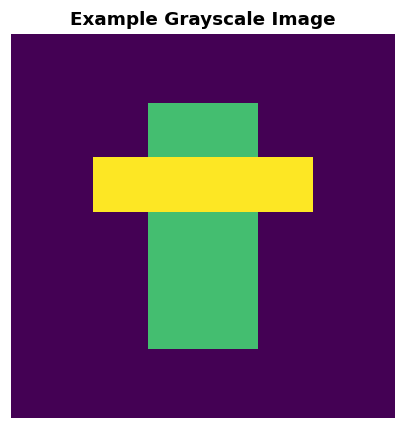

In [28]:
image = np.zeros((28, 28))
image[5:23, 10:18] = 0.7
image[9:13, 6:22] = 1.0

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image)
ax.set_title("Example Grayscale Image")
ax.axis("off")

fig.tight_layout()
plt.show()

### 8.2 图像网格

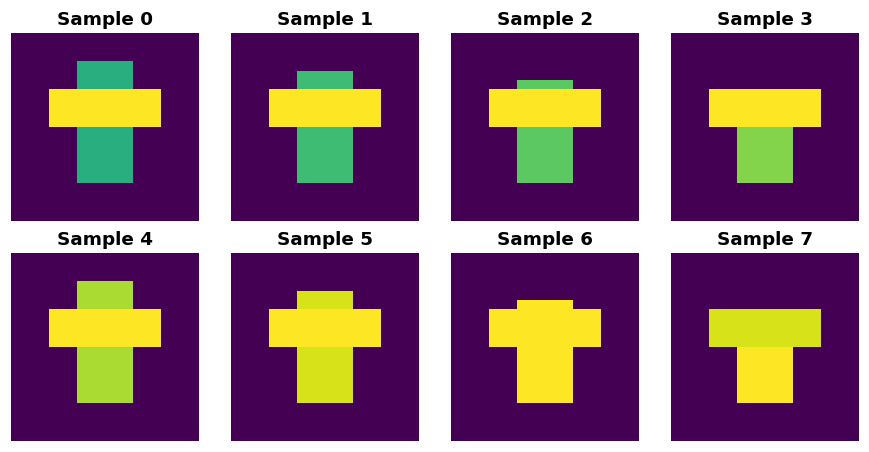

In [29]:
images = []
for shift in range(8):
    img = np.zeros((20, 20))
    start = 3 + shift % 4
    img[start:16, 7:13] = 0.5 + 0.05 * shift
    img[6:10, 4:16] = 0.8
    images.append(img)

fig, axes = plt.subplots(2, 4, figsize=(8, 4), constrained_layout=True)

for index, ax in enumerate(axes.flat):
    ax.imshow(images[index])
    ax.set_title(f"Sample {index}")
    ax.axis("off")

plt.show()

图像分类中常用图像网格检查：

- 图片和标签是否对应；
- 数据增强是否合理；
- 通道顺序是否正确；
- 图片是否归一化或显示异常；
- 错分样本具有哪些共同特点。

### 8.3 超参数热力图

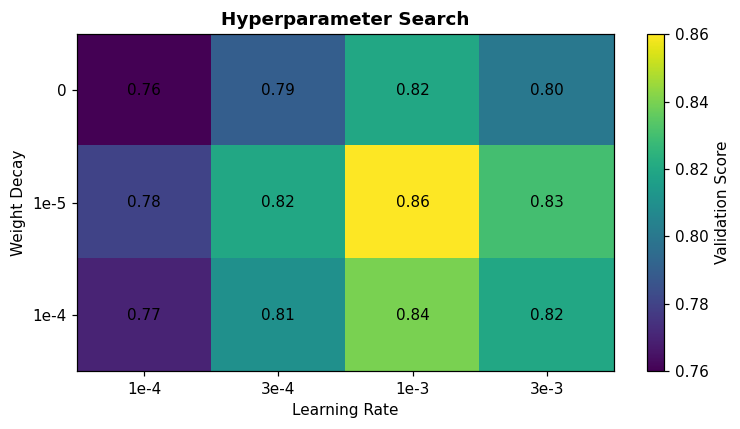

In [30]:
learning_rate_labels = ["1e-4", "3e-4", "1e-3", "3e-3"]
weight_decay_labels = ["0", "1e-5", "1e-4"]
validation_scores = np.array([
    [0.76, 0.79, 0.82, 0.80],
    [0.78, 0.82, 0.86, 0.83],
    [0.77, 0.81, 0.84, 0.82],
])

fig, ax = plt.subplots(figsize=(7, 4))
image = ax.imshow(validation_scores, aspect="auto")

ax.set_xticks(np.arange(len(learning_rate_labels)), learning_rate_labels)
ax.set_yticks(np.arange(len(weight_decay_labels)), weight_decay_labels)
ax.set(
    title="Hyperparameter Search",
    xlabel="Learning Rate",
    ylabel="Weight Decay",
)

for row in range(validation_scores.shape[0]):
    for col in range(validation_scores.shape[1]):
        ax.text(
            col,
            row,
            f"{validation_scores[row, col]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Validation Score")
fig.tight_layout()
plt.show()

## 9. NumPy、Pandas、PyTorch 衔接

### 9.1 NumPy 数组

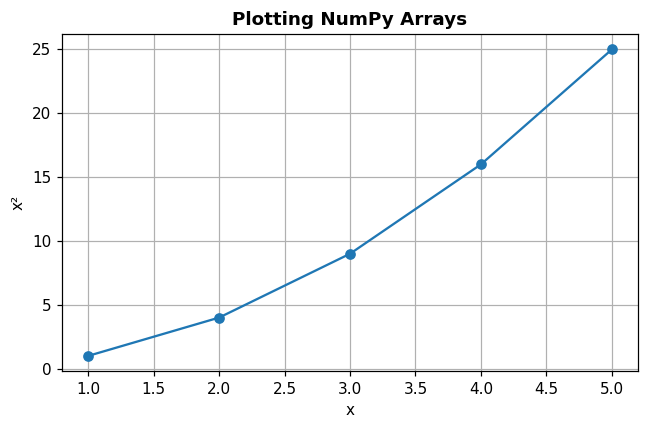

In [31]:
x_numpy = np.arange(1, 6)
y_numpy = x_numpy ** 2

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_numpy, y_numpy, marker="o")
ax.set(
    title="Plotting NumPy Arrays",
    xlabel="x",
    ylabel="x²",
)
ax.grid(True)

fig.tight_layout()
plt.show()

### 9.2 Pandas DataFrame

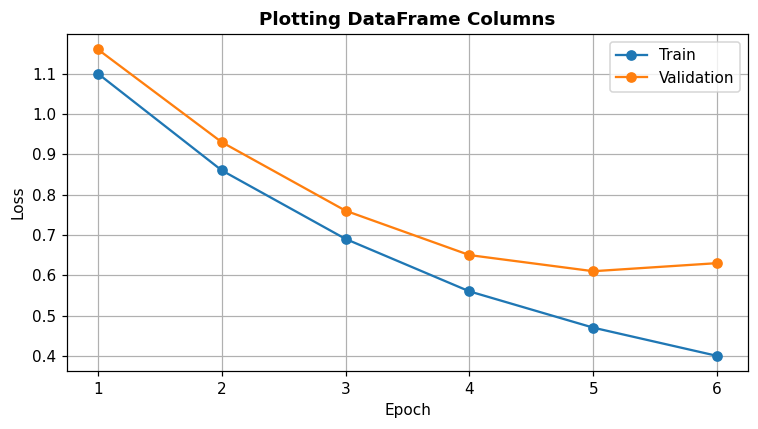

In [32]:
metrics_df = pd.DataFrame({
    "epoch": np.arange(1, 7),
    "train_loss": [1.10, 0.86, 0.69, 0.56, 0.47, 0.40],
    "val_loss": [1.16, 0.93, 0.76, 0.65, 0.61, 0.63],
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(metrics_df["epoch"], metrics_df["train_loss"], marker="o", label="Train")
ax.plot(metrics_df["epoch"], metrics_df["val_loss"], marker="o", label="Validation")
ax.set(
    title="Plotting DataFrame Columns",
    xlabel="Epoch",
    ylabel="Loss",
)
ax.legend()
ax.grid(True)

fig.tight_layout()
plt.show()

### 9.3 PyTorch Tensor

CPU Tensor 通常可以直接绘制，但项目中建议明确转换：

```python
values = tensor.detach().cpu().numpy()
```

含义：

- `detach()`：断开计算图；
- `cpu()`：确保数据位于 CPU；
- `numpy()`：转换成 NumPy 数组。

GPU Tensor 不能直接调用 `.numpy()`：

```python
# 错误
tensor_cuda.numpy()

# 正确
tensor_cuda.detach().cpu().numpy()
```

标量 Tensor 常用：

```python
loss_value = loss.detach().item()
```

训练时通常先把每个 batch 的标量保存到 Python 列表，再统一绘图。

### 9.4 训练循环中记录指标的典型方式

```python
history = {
    "train_loss": [],
    "val_loss": [],
}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(...)
    val_loss = validate(...)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

# 训练结束后统一绘制
```

不要在每个 batch 都创建并显示图形，否则训练会明显变慢。

## 10. 可复用绘图函数

把固定模板封装为函数，可以：

- 减少重复代码；
- 保证不同实验图形风格一致；
- 更方便保存论文图、实验报告图和 README 图。

In [33]:
def plot_training_history(
    history: dict[str, list[float]],
    *,
    save_path: str | Path | None = None,
) -> tuple[plt.Figure, np.ndarray]:
    """绘制训练/验证 Loss 和 Accuracy 曲线。"""

    required_keys = {"train_loss", "val_loss", "train_acc", "val_acc"}
    missing_keys = required_keys.difference(history)

    if missing_keys:
        raise KeyError(f"history 缺少字段: {sorted(missing_keys)}")

    lengths = {len(history[key]) for key in required_keys}
    if len(lengths) != 1:
        raise ValueError("history 中各指标长度必须一致")

    epochs = np.arange(1, lengths.pop() + 1)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4),
        constrained_layout=True,
    )

    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation")
    axes[0].set(
        title="Loss Curves",
        xlabel="Epoch",
        ylabel="Loss",
    )
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history["train_acc"], marker="o", label="Train")
    axes[1].plot(epochs, history["val_acc"], marker="o", label="Validation")
    axes[1].set(
        title="Accuracy Curves",
        xlabel="Epoch",
        ylabel="Accuracy",
        ylim=(0, 1),
    )
    axes[1].legend()
    axes[1].grid(True)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")

    return fig, axes

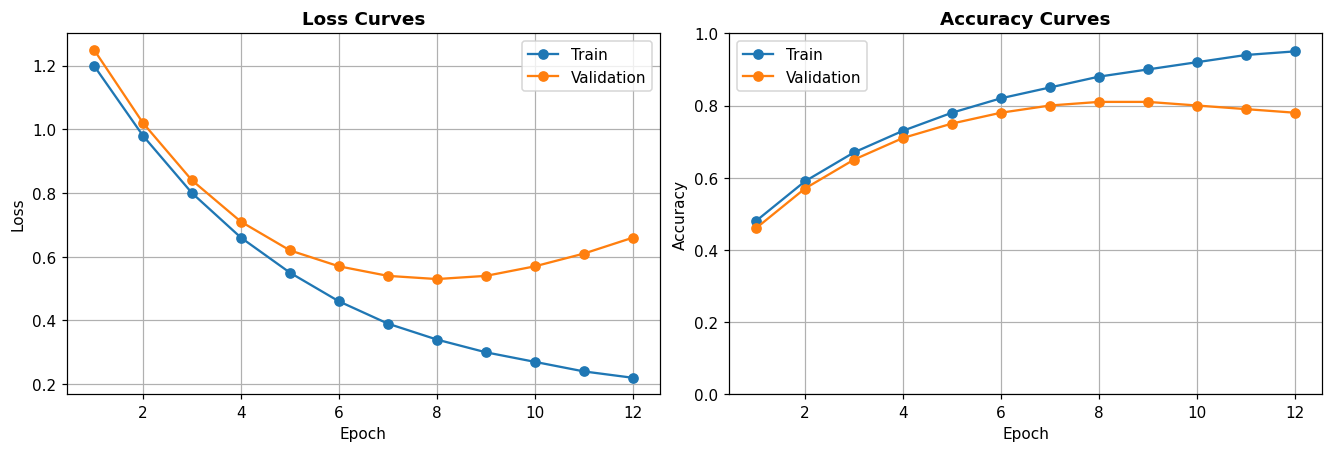

In [34]:
fig, axes = plot_training_history(history)
plt.show()

In [35]:
def plot_confusion_matrix(
    matrix: np.ndarray,
    labels: list[str],
) -> tuple[plt.Figure, plt.Axes]:
    """绘制带数值标注的混淆矩阵。"""

    matrix = np.asarray(matrix)

    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError("matrix 必须是方阵")

    if matrix.shape[0] != len(labels):
        raise ValueError("标签数量必须与矩阵大小一致")

    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(matrix)

    ax.set(
        title="Confusion Matrix",
        xlabel="Predicted Label",
        ylabel="True Label",
    )
    ax.set_xticks(np.arange(len(labels)), labels)
    ax.set_yticks(np.arange(len(labels)), labels)

    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(
                col,
                row,
                str(matrix[row, col]),
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax, label="Count")
    fig.tight_layout()

    return fig, ax

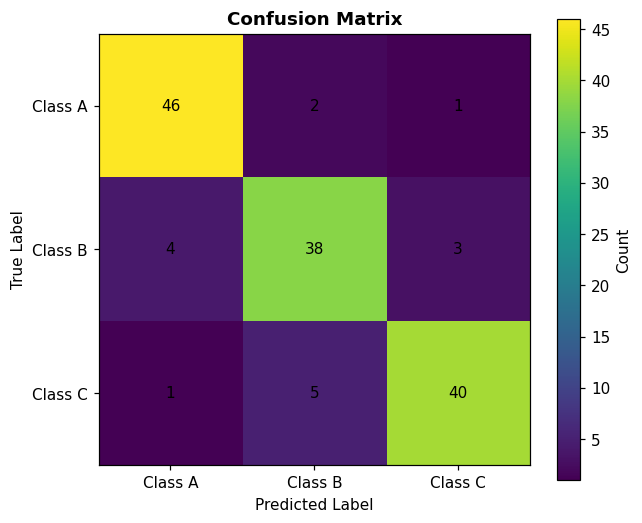

In [36]:
fig, ax = plot_confusion_matrix(confusion_matrix, cm_labels)
plt.show()

## 11. 图片保存与资源管理

### 11.1 保存图片

必须在关闭图形之前保存：

```python
fig.savefig(
    "outputs/loss_curve.png",
    dpi=300,
    bbox_inches="tight",
)
```

常见格式：

- PNG：适合网页、README 和普通报告；
- PDF / SVG：矢量图，适合论文和放大查看；
- JPG：有损压缩，不适合包含文字和细线的实验图。

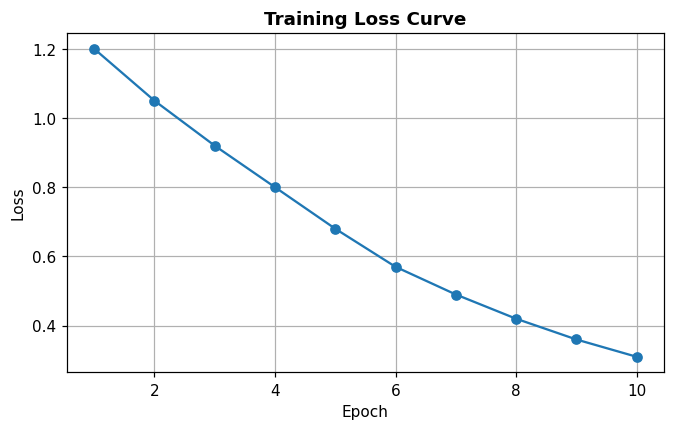

图片已保存到: /mnt/data/matplotlib_outputs/loss_curve.png


In [37]:
output_dir = Path("matplotlib_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

save_path = output_dir / "loss_curve.png"

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, train_loss, marker="o")
ax.set(
    title="Training Loss Curve",
    xlabel="Epoch",
    ylabel="Loss",
)
ax.grid(True)

fig.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("图片已保存到:", save_path.resolve())

### 11.2 循环绘图后关闭 Figure

批量生成很多图时应主动关闭：

```python
for name in names:
    fig, ax = plt.subplots()
    ...
    fig.savefig(...)
    plt.close(fig)
```

否则大量 Figure 会占用内存。

In [38]:
batch_output_dir = output_dir / "batch_examples"
batch_output_dir.mkdir(parents=True, exist_ok=True)

for index in range(3):
    fig, ax = plt.subplots(figsize=(5, 3))
    x_batch = np.arange(1, 6)
    y_batch = x_batch * (index + 1)

    ax.plot(x_batch, y_batch, marker="o")
    ax.set(
        title=f"Batch Figure {index}",
        xlabel="X",
        ylabel="Y",
    )

    fig.savefig(
        batch_output_dir / f"figure_{index}.png",
        bbox_inches="tight",
    )
    plt.close(fig)

print("批量图片数量:", len(list(batch_output_dir.glob("*.png"))))

批量图片数量: 3


## 12. 常见错误与速查表

### 12.1 常见错误

#### 错误一：`x` 和 `y` 长度不同

```python
plt.plot([1, 2, 3], [10, 20])
```

会报错，因为每个横坐标都需要对应一个纵坐标。

#### 错误二：直接把 GPU Tensor 转为 NumPy

```python
tensor_cuda.numpy()
```

应改为：

```python
tensor_cuda.detach().cpu().numpy()
```

#### 错误三：在 `show()` 或 `close()` 后才保存

推荐顺序：

```python
fig.savefig(...)
plt.show()
```

#### 错误四：所有指标都挤在同一个纵轴

Loss 和 Accuracy 数值含义不同，优先使用子图。

#### 错误五：图例不显示

只有设置了 `label` 后，`legend()` 才有内容：

```python
ax.plot(x, y, label="Train")
ax.legend()
```

#### 错误六：标签重叠

可以使用：

```python
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
```

#### 错误七：训练过程中频繁 `plt.show()`

训练时只记录数值，训练结束或每隔较长周期再绘制。

### 12.2 快速速查表

| 目的 | 常用代码 |
|---|---|
| 创建单图 | `fig, ax = plt.subplots()` |
| 创建多图 | `fig, axes = plt.subplots(r, c)` |
| 折线 | `ax.plot(x, y)` |
| 散点 | `ax.scatter(x, y)` |
| 柱状图 | `ax.bar(x, y)` |
| 水平柱状图 | `ax.barh(y, x)` |
| 直方图 | `ax.hist(values, bins=20)` |
| 箱线图 | `ax.boxplot(groups)` |
| 图片/矩阵 | `ax.imshow(matrix)` |
| 标题 | `ax.set_title("...")` |
| 坐标名 | `ax.set_xlabel(...)`、`ax.set_ylabel(...)` |
| 范围 | `ax.set_xlim(...)`、`ax.set_ylim(...)` |
| 图例 | `ax.legend()` |
| 网格 | `ax.grid(True)` |
| 水平参考线 | `ax.axhline(y)` |
| 垂直参考线 | `ax.axvline(x)` |
| 文本标注 | `ax.annotate(...)` |
| 对数坐标 | `ax.set_xscale("log")` |
| 自动布局 | `fig.tight_layout()` |
| 保存图片 | `fig.savefig(path, dpi=300, bbox_inches="tight")` |
| 关闭图片 | `plt.close(fig)` |

### 12.3 绘图方法选择

```text
想看随 Epoch 的变化        → 折线图
想看两个连续变量的关系      → 散点图
想比较不同模型或类别        → 柱状图
想看数值分布                → 直方图 / 箱线图
想看均值与不确定性          → 误差棒 / 阴影区域
想看分类错误分布            → 混淆矩阵
想看分类阈值的整体表现      → ROC / PR 曲线
想看回归误差模式            → 残差图
想看图像或二维矩阵          → imshow
想看多个超参数组合          → 热力图
```

## 13. 综合练习

### 练习 1：训练曲线

构造 20 个 Epoch 的训练 Loss 和验证 Loss：

- 训练 Loss 持续下降；
- 验证 Loss 先下降后上升；
- 自动找出验证 Loss 最低的 Epoch；
- 用竖线和文字标记最佳 Epoch。

### 练习 2：模型比较

准备 4 个模型的 Accuracy、Precision、Recall、F1：

- 使用多个子图分别展示；
- 每个柱子上显示数值；
- 所有指标纵轴固定为 `[0, 1]`。

### 练习 3：分类结果分析

给定真实标签和预测标签：

- 手动构造混淆矩阵；
- 绘制类别分布；
- 观察哪个类别最容易被误判。

### 练习 4：回归分析

生成一组真实值与预测值：

- 画真实值与预测值散点图；
- 添加理想对角线；
- 计算残差并绘制残差图；
- 判断是否存在系统性偏差。

### 练习 5：封装函数

编写一个函数：

```python
plot_metric(
    train_values,
    val_values,
    metric_name,
    save_path=None,
)
```

要求能够检查长度、绘图、添加图例，并可选保存图片。

## 最后总结

机器学习中使用 Matplotlib，最值得熟练掌握的是：

1. `fig, ax = plt.subplots()`；
2. `plot()`、`scatter()`、`bar()`、`hist()`、`imshow()`；
3. `set()`、`legend()`、`grid()`、`axhline()`、`axvline()`；
4. `subplots()` 多图布局；
5. 训练/验证曲线、模型对比、混淆矩阵和残差图；
6. Tensor 转换：`tensor.detach().cpu().numpy()`；
7. 保存：`fig.savefig(..., dpi=300, bbox_inches="tight")`；
8. 批量生成图后：`plt.close(fig)`。

真正做项目时，先保证图形能够回答一个明确问题，再考虑样式美化。